In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. SETTINGS


In [4]:
DATA_DIR = "."  # folder where the CSVs live
CITY_FILES = {
    "Amman": "Amman.csv",
    "Irbid": "Irbid.csv",
    "Zarqa": "Zarqa.csv",
}

POLLUTANTS = ["PM10", "NO2", "SO2"]

# where to save tables/figures
OUTPUT_DIR = "./Descriptive statistics"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. LOAD AND COMBINE DATA

In [5]:
def load_city_data(city_name, filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    # Parse date
    df["Date"] = pd.to_datetime(df["Date"])
    df["City"] = city_name
    return df

dfs = []
for city, fname in CITY_FILES.items():
    dfs.append(load_city_data(city, fname))

data = pd.concat(dfs, ignore_index=True)

# Create time-related columns
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Month_name"] = data["Date"].dt.strftime("%b")

### Optional: define seasons (DJF, MAM, JJA, SON)

In [6]:
def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

data["Season"] = data["Month"].apply(month_to_season)

## 3. DESCRIPTIVE STATISTICS


In [9]:
def descriptive_stats(df, group_cols, pollutants):
    """
    Returns a DataFrame of descriptive statistics:
    N, missing, mean, sd, median, IQR, min, max for each pollutant.
    """
    rows = []
    grouped = df.groupby(group_cols)
    for keys, g in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)
        key_dict = dict(zip(group_cols, keys))
        for pol in pollutants:
            series = g[pol]
            valid = series.dropna()
            desc = {
                **key_dict,
                "Pollutant": pol,
                "N": series.shape[0],
                "N_valid": valid.shape[0],
                "N_missing": series.isna().sum(),
                "Mean": valid.mean(),
                "SD": valid.std(),
                "Median": valid.median(),
                "P25": valid.quantile(0.25),
                "P75": valid.quantile(0.75),
                "IQR": valid.quantile(0.75) - valid.quantile(0.25),
                "Min": valid.min(),
                "Max": valid.max(),
            }
            rows.append(desc)
    return pd.DataFrame(rows)

# City-level descriptive stats (this is your main Table for the paper)
city_desc = descriptive_stats(data, ["City"], POLLUTANTS)
city_desc.to_csv(os.path.join(OUTPUT_DIR, "descriptive_by_city.csv"), index=False)
print("Descriptive stats by city:")
city_desc

Descriptive stats by city:


C:\Users\user\AppData\Local\Temp\ipykernel_13368\1549626689.py:8: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for keys, g in grouped:


,City,Pollutant,N,N_valid,N_missing,Mean,SD,Median,P25,P75,IQR,Min,Max
0,Amman,PM10,1826,1792,34,68.865154,42.758523,56.283333,42.016667,82.445833,40.429167,12.206667,416.037960
1,Amman,NO2,1826,1794,32,22.660142,7.214882,21.782768,17.993021,26.467500,8.474479,6.735619,68.439503
2,Amman,SO2,1826,1794,32,8.663207,6.412493,6.821845,4.700625,10.584551,5.883926,0.637750,92.721143
3,Irbid,PM10,1826,1787,39,48.969001,24.393810,41.900000,33.699424,57.900000,24.200576,9.260000,209.000000
4,Irbid,NO2,1826,1793,33,18.324276,7.112056,17.675000,13.205000,23.100000,9.895000,1.606223,47.050000
5,Irbid,SO2,1826,1729,97,8.939026,8.000003,5.850000,3.530000,12.700000,9.170000,0.058000,54.500000
6,Zarqa,PM10,1826,1753,73,78.736577,36.925987,72.550000,51.500000,97.850000,46.350000,10.111606,348.706244
7,Zarqa,NO2,1826,1795,31,18.506392,7.157915,16.750000,13.400000,21.800000,8.400000,2.148045,48.100000
8,Zarqa,SO2,1826,1795,31,8.176629,6.654670,6.325000,3.607500,9.912500,6.305000,0.206000,37.850000


In [10]:
# Seasonal descriptive stats (for Supplementary Material if you want)
season_desc = descriptive_stats(data, ["City", "Season"], POLLUTANTS)
season_desc.to_csv(os.path.join(OUTPUT_DIR, "descriptive_by_city_season.csv"), index=False)

# Monthly descriptive stats (for plotting or Suppl.)
month_desc = descriptive_stats(data, ["City", "Year", "Month"], POLLUTANTS)
month_desc.to_csv(os.path.join(OUTPUT_DIR, "descriptive_by_city_year_month.csv"), index=False)


## 4. PLOTS: SEASONAL / MONTHLY VARIATION


In [17]:
def plot_monthly_means(df, pollutant, output_dir=OUTPUT_DIR):
    """
    Plot monthly mean pollutant concentrations by city (averaged over years).
    """
    # Compute monthly means collapsed over all years
    monthly_means = (
        df.groupby(["City", "Month", "Month_name"])[pollutant]
          .mean()
          .reset_index()
    )
    # Ensure months in correct order
    monthly_means = monthly_means.sort_values("Month")

    plt.figure(figsize=(10, 6))
    for city in monthly_means["City"].unique():
        sub = monthly_means[monthly_means["City"] == city]
        plt.plot(
            sub["Month_name"],
            sub[pollutant],
            marker="o",
            label=city,
        )
    plt.xlabel("Month")
    plt.ylabel(f"Mean {pollutant}")
    plt.title(f"Monthly mean {pollutant} by city (all years combined)")
    plt.legend()
    plt.tight_layout()
    fname = os.path.join(output_dir, f"monthly_mean_{pollutant}.png")
    plt.savefig(fname, dpi=300)
    plt.close()
    print(f"Saved {fname}")

def plot_season_boxplots(df, pollutant, output_dir=OUTPUT_DIR):
    """
    Boxplots of pollutant by season and city.
    """
    plt.figure(figsize=(8, 6))
    # Create combined label City-Season
    df["City_Season"] = df["City"] + " - " + df["Season"]

    # Prepare data
    order = sorted(df["City_Season"].unique())
    data_to_plot = [df.loc[df["City_Season"] == grp, pollutant].dropna()
                    for grp in order]

    plt.boxplot(data_to_plot, labels=order, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(pollutant)
    plt.title(f"{pollutant} distribution by city and season")
    plt.tight_layout()
    fname = os.path.join(output_dir, f"boxplot_season_{pollutant}.png")
    plt.savefig(fname, dpi=300)
    plt.close()
    print(f"Saved {fname}")

def plot_time_series(df, pollutant, city, output_dir=OUTPUT_DIR):
    """
    Simple time-series plot for each pollutant in each city.
    """
    sub = df[df["City"] == city].sort_values("Date")
    plt.figure(figsize=(10, 4))
    plt.plot(sub["Date"], sub[pollutant], linewidth=.8)
    plt.xlabel("Date")
    plt.ylabel(pollutant)
    plt.title(f"{pollutant} time series in {city}")
    plt.tight_layout()
    fname = os.path.join(output_dir, f"time_series_{city}_{pollutant}.png")
    plt.savefig(fname, dpi=300)
    plt.close()
    print(f"Saved {fname}")

In [19]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]
data["Season"] = pd.Categorical(data["Season"], categories=season_order, ordered=True)

month_order = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
month_name_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

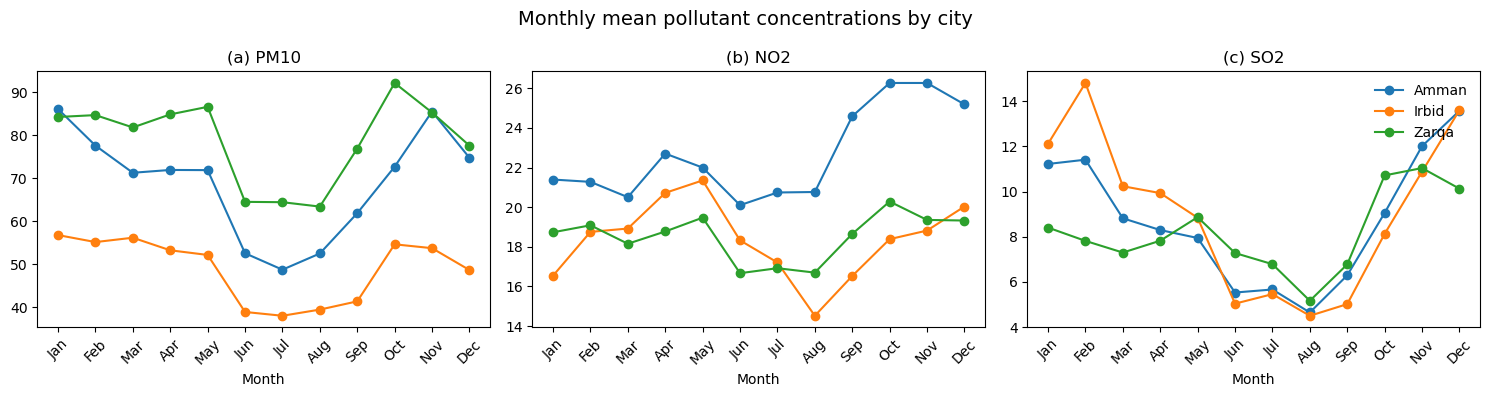

In [45]:
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
panel_labels = ["(a)", "(b)", "(c)"]

for i, pol in enumerate(POLLUTANTS):
    ax = axes1[i]
    # Compute monthly means averaged over all years
    monthly_means = (
        data.groupby(["City", "Month"])[pol]
            .mean()
            .reset_index()
    )
    # Map month numbers to ordered month names
    monthly_means["Month_name"] = monthly_means["Month"].map(
        dict(zip(month_order, month_name_order))
    )

    for city in CITY_FILES.keys():
        sub = monthly_means[monthly_means["City"] == city].sort_values("Month")
        ax.plot(sub["Month_name"], sub[pol], marker="o", label=city)

    ax.set_title(panel_labels[i]+' '+pol)
    ax.set_xlabel("Month")
    #if i == 0:
    #    ax.set_ylabel(f"Mean {pol}")
    ax.set_xticks(month_name_order)
    ax.tick_params(axis="x", rotation=45)
    # Add panel label
    #ax.text(0.02, 0.95, panel_labels[i], transform=ax.transAxes,
    #        va="top", ha="left", fontweight="bold")

axes1[-1].legend(loc="upper right", frameon=False)
fig1.suptitle("Monthly mean pollutant concentrations by city", size=14)
fig1.tight_layout()
plt.show()
fig1.savefig(os.path.join(OUTPUT_DIR, "Figure1_monthly_means.png"), dpi=300)
plt.close(fig1)

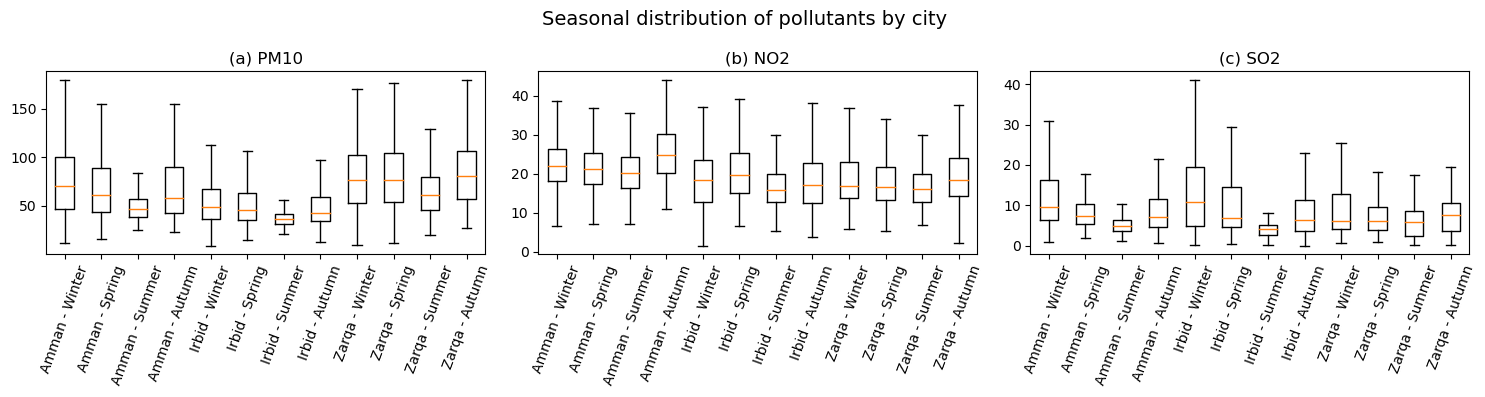

In [36]:
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for i, pol in enumerate(POLLUTANTS):
    ax = axes2[i]
    # Create a combined label for City-Season
    df_pol = data[["City", "Season", pol]].dropna().copy()
    df_pol["City_Season"] = df_pol["City"] + " - " + df_pol["Season"].astype(str)

    # Order groups
    # e.g., Amman-Winter, Amman-Spring, ..., Irbid-Winter,...
    groups = []
    labels = []
    for city in CITY_FILES.keys():
        for season in season_order:
            label = f"{city} - {season}"
            sub = df_pol[df_pol["City_Season"] == label][pol]
            if len(sub) > 0:
                groups.append(sub)
                labels.append(label)

    ax.boxplot(groups, labels=labels, showfliers=False)
    ax.set_title(panel_labels[i]+' '+pol)
    ax.tick_params(axis="x", rotation=70)
    #if i == 0:
    #    ax.set_ylabel(pol)
    # Panel label
    #ax.text(0.02, 0.95, panel_labels_2[i], transform=ax.transAxes,
            #va="top", ha="left", fontweight="bold")

fig2.suptitle("Seasonal distribution of pollutants by city", size=14)
fig2.tight_layout()
fig2.savefig(os.path.join(OUTPUT_DIR, "Figure2_seasonal_boxplots.png"), dpi=300)
plt.show()
plt.close(fig2)

(a) Amman - PM10
(b) Amman - NO2
(c) Amman - SO2
(d) Irbid - PM10
(e) Irbid - NO2
(f) Irbid - SO2
(g) Zarqa - PM10
(h) Zarqa - NO2
(i) Zarqa - SO2


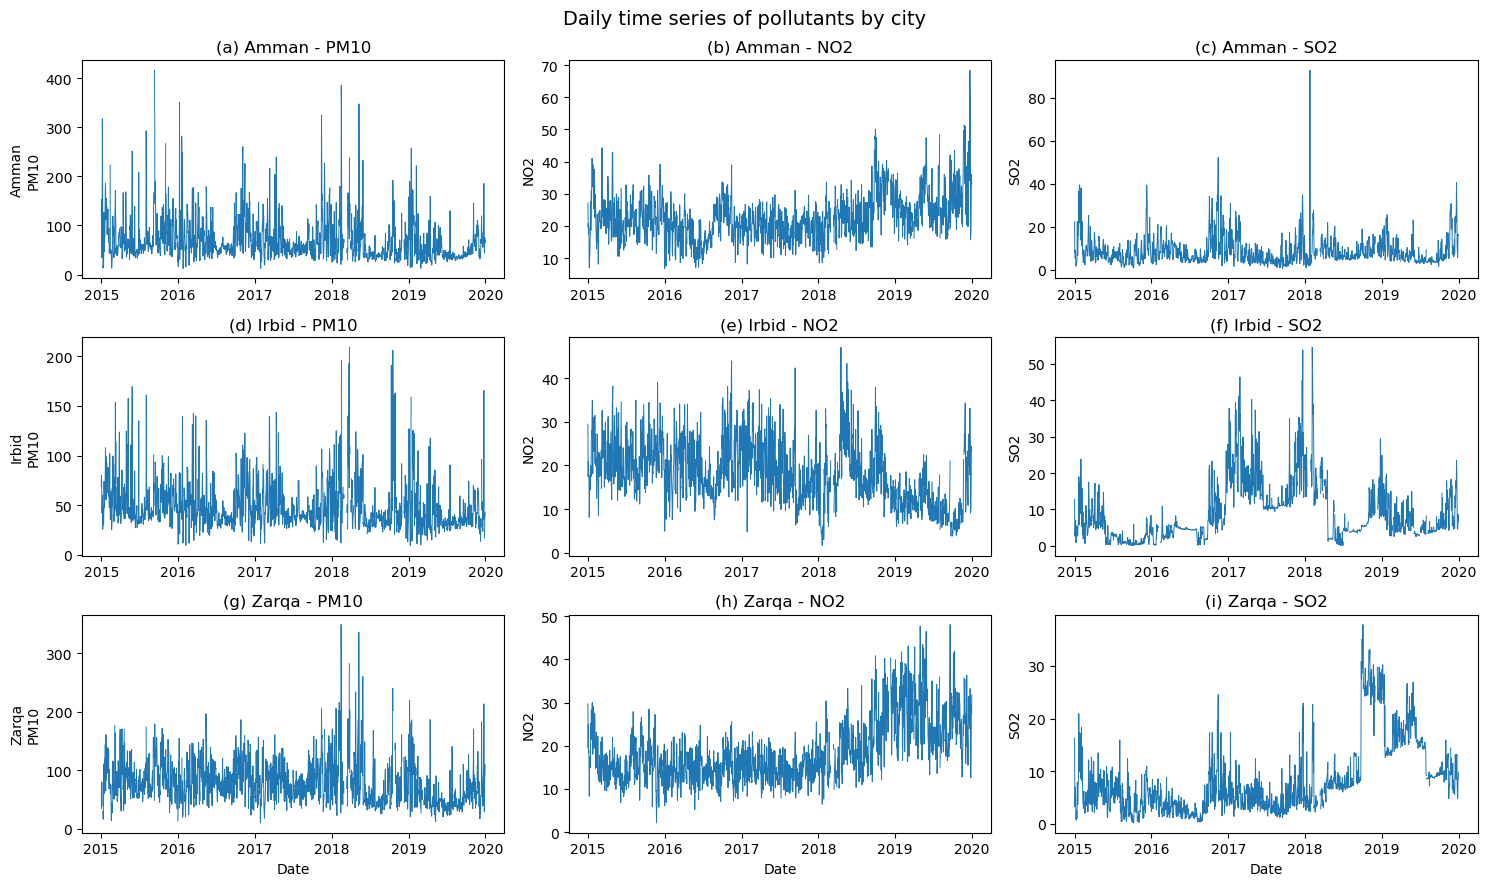

All multi-panel figures saved in: ./Descriptive statistics


In [44]:
fig3, axes3 = plt.subplots(3, 3, figsize=(15, 9), sharex=False)
panel_labels_3 = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]

label_index = 0

for r, city in enumerate(CITY_FILES.keys()):
    for c, pol in enumerate(POLLUTANTS):
        ax = axes3[r, c]
        sub = data[data["City"] == city].sort_values("Date")
        ax.plot(sub["Date"], sub[pol], linewidth=.7)
        if r == 2:
            ax.set_xlabel("Date")
        if c == 0:
            ax.set_ylabel(f"{city}\n{pol}")
        else:
            ax.set_ylabel(pol)
        ax.set_title(f"{panel_labels_3[label_index]} {city} - {pol}")
        print(f"{panel_labels_3[label_index]} {city} - {pol}")
        # Panel label
        #ax.text(0.02, 0.95, panel_labels_3[label_index], transform=ax.transAxes,
        #        va="top", ha="left", fontweight="bold")
        label_index += 1

fig3.suptitle("Daily time series of pollutants by city", size=14)
fig3.tight_layout()
fig3.savefig(os.path.join(OUTPUT_DIR, "Figure3_time_series.png"), dpi=300)
plt.show()
plt.close(fig3)

print("All multi-panel figures saved in:", OUTPUT_DIR)